In [13]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import numpy as np

# Data manipulation
import pandas as pd

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Remove warnings
import warnings
warnings.filterwarnings('ignore')


In [12]:
education.shape


(202, 29)

In [13]:
education.info()

<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Countries and areas                      202 non-null    str    
 1   Latitude                                 202 non-null    float64
 2   Longitude                                202 non-null    float64
 3   OOSR_Pre0Primary_Age_Male                202 non-null    int64  
 4   OOSR_Pre0Primary_Age_Female              202 non-null    int64  
 5   OOSR_Primary_Age_Male                    202 non-null    int64  
 6   OOSR_Primary_Age_Female                  202 non-null    int64  
 7   OOSR_Lower_Secondary_Age_Male            202 non-null    int64  
 8   OOSR_Lower_Secondary_Age_Female          202 non-null    int64  
 9   OOSR_Upper_Secondary_Age_Male            202 non-null    int64  
 10  OOSR_Upper_Secondary_Age_Female          202 non-null    int6

In [14]:
education.isnull().sum()


Countries and areas                        0
Latitude                                   0
Longitude                                  0
OOSR_Pre0Primary_Age_Male                  0
OOSR_Pre0Primary_Age_Female                0
OOSR_Primary_Age_Male                      0
OOSR_Primary_Age_Female                    0
OOSR_Lower_Secondary_Age_Male              0
OOSR_Lower_Secondary_Age_Female            0
OOSR_Upper_Secondary_Age_Male              0
OOSR_Upper_Secondary_Age_Female            0
Completion_Rate_Primary_Male               0
Completion_Rate_Primary_Female             0
Completion_Rate_Lower_Secondary_Male       0
Completion_Rate_Lower_Secondary_Female     0
Completion_Rate_Upper_Secondary_Male       0
Completion_Rate_Upper_Secondary_Female     0
Grade_2_3_Proficiency_Reading              0
Grade_2_3_Proficiency_Math                 0
Primary_End_Proficiency_Reading            0
Primary_End_Proficiency_Math               0
Lower_Secondary_End_Proficiency_Reading    0
Lower_Seco

In [15]:
education.duplicated().sum()

np.int64(0)

In [16]:
education.describe()

,Latitude,Longitude,OOSR_Pre0Primary_Age_Male,OOSR_Pre0Primary_Age_Female,OOSR_Primary_Age_Male,OOSR_Primary_Age_Female,OOSR_Lower_Secondary_Age_Male,OOSR_Lower_Secondary_Age_Female,OOSR_Upper_Secondary_Age_Male,OOSR_Upper_Secondary_Age_Female,...,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Youth_15_24_Literacy_Rate_Male,Youth_15_24_Literacy_Rate_Female,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,...,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,25.081422,55.166928,19.658416,19.282178,5.282178,5.569307,8.707921,8.831683,20.292079,19.975248,...,10.717822,10.376238,25.787129,24.450495,35.801980,35.084158,18.914010,94.942574,34.392574,6.000000
std,16.813639,45.976287,25.007604,25.171147,9.396442,10.383092,13.258203,14.724717,21.485592,23.140376,...,24.866101,22.484423,33.181384,31.965467,45.535186,45.249643,10.828184,29.769338,29.978206,5.273136
min,0.023559,0.824782,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.685062,18.665678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.355000,97.200000,9.000000,2.302500
50%,21.207861,43.518091,9.000000,7.000000,1.000000,1.000000,2.000000,2.000000,15.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.550000,101.850000,24.850000,4.585000
75%,39.901792,77.684945,31.000000,30.000000,6.000000,6.750000,12.750000,10.750000,32.750000,30.000000,...,0.000000,0.000000,56.750000,50.750000,94.000000,96.750000,27.692500,107.300000,59.975000,8.655000
max,64.963051,178.065032,96.000000,96.000000,58.000000,67.000000,61.000000,70.000000,84.000000,89.000000,...,99.000000,89.000000,89.000000,94.000000,100.000000,100.000000,46.080000,142.500000,136.600000,28.180000


In [6]:
grouped_data = education.groupby('Countries and areas')

# Compute average completion rates for each countries and education level
completion_rates = grouped_data[['Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
                                'Completion_Rate_Lower_Secondary_Male', 'Completion_Rate_Lower_Secondary_Female',
                                'Completion_Rate_Upper_Secondary_Male', 'Completion_Rate_Upper_Secondary_Female']].mean()
top_10_countries_completion_rates=completion_rates.sort_values(by=['Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
                                'Completion_Rate_Lower_Secondary_Male', 'Completion_Rate_Lower_Secondary_Female',
                                'Completion_Rate_Upper_Secondary_Male', 'Completion_Rate_Upper_Secondary_Female'],ascending=False).head(10)
top_10_countries_completion_rates


,Completion_Rate_Primary_Male,Completion_Rate_Primary_Female,Completion_Rate_Lower_Secondary_Male,Completion_Rate_Lower_Secondary_Female,Completion_Rate_Upper_Secondary_Male,Completion_Rate_Upper_Secondary_Female
Countries and areas,,,,,,
North Korea,100.0,100.0,100.0,100.0,100.0,100.0
Kazakhstan,100.0,100.0,100.0,100.0,95.0,96.0
Belarus,100.0,100.0,100.0,100.0,91.0,94.0
Turkmenistan,100.0,100.0,99.0,100.0,93.0,95.0
Georgia,100.0,100.0,98.0,98.0,79.0,83.0
Ukraine,100.0,99.0,100.0,100.0,97.0,97.0
Cuba,100.0,98.0,95.0,98.0,85.0,86.0
Kyrgyzstan,99.0,100.0,99.0,99.0,89.0,85.0
Serbia,99.0,100.0,99.0,99.0,71.0,81.0


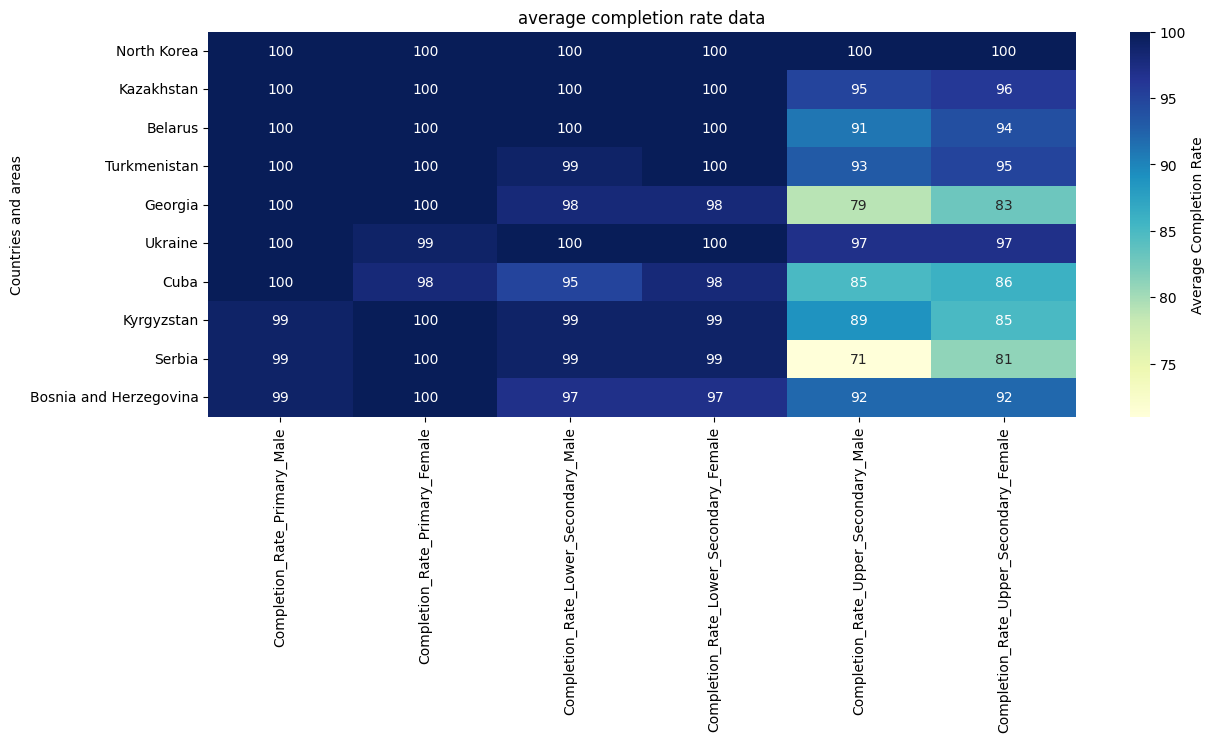

In [17]:
plt.figure(figsize=(14, 5))
sns.heatmap(top_10_countries_completion_rates, annot=True, cmap="YlGnBu", fmt=".0f", cbar_kws={'label': 'Average Completion Rate'})
plt.title("Average Completion Rates of top 10 countries and Education Levels")
plt.show()

In [18]:
least_10_countries=completion_rates.sort_values(by=['Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
                                'Completion_Rate_Lower_Secondary_Male', 'Completion_Rate_Lower_Secondary_Female',
                                'Completion_Rate_Upper_Secondary_Male', 'Completion_Rate_Upper_Secondary_Female'],ascending=True).head(10)
least_10_countries

,Completion_Rate_Primary_Male,Completion_Rate_Primary_Female,Completion_Rate_Lower_Secondary_Male,Completion_Rate_Lower_Secondary_Female,Completion_Rate_Upper_Secondary_Male,Completion_Rate_Upper_Secondary_Female
Countries and areas,,,,,,
Andorra,0.0,0.0,0.0,0.0,0.0,0.0
Anguilla,0.0,0.0,0.0,0.0,0.0,0.0
Antigua and Barbuda,0.0,0.0,0.0,0.0,0.0,0.0
Australia,0.0,0.0,0.0,0.0,0.0,0.0
Austria,0.0,0.0,0.0,0.0,0.0,0.0
Azerbaijan,0.0,0.0,0.0,0.0,0.0,0.0
Bahrain,0.0,0.0,0.0,0.0,0.0,0.0
Belgium,0.0,0.0,0.0,0.0,0.0,0.0
Bolivia,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
education['Gender_Gap_Primary'] = education['Completion_Rate_Primary_Male'] - education['Completion_Rate_Primary_Female']
education['Gender_Gap_Lower_Secondary'] = education['Completion_Rate_Lower_Secondary_Male'] - education['Completion_Rate_Lower_Secondary_Female']
education['Gender_Gap_Upper_Secondary'] = education['Completion_Rate_Upper_Secondary_Male'] - education['Completion_Rate_Upper_Secondary_Female']


overall_gender_gap = education[['Gender_Gap_Primary', 'Gender_Gap_Lower_Secondary', 'Gender_Gap_Upper_Secondary']].mean().mean()


print(f'Overall Gender Gap in Completion Rates: {overall_gender_gap}')

Overall Gender Gap in Completion Rates: -0.40759075907590764


Text(0, 0.5, 'gender gap')

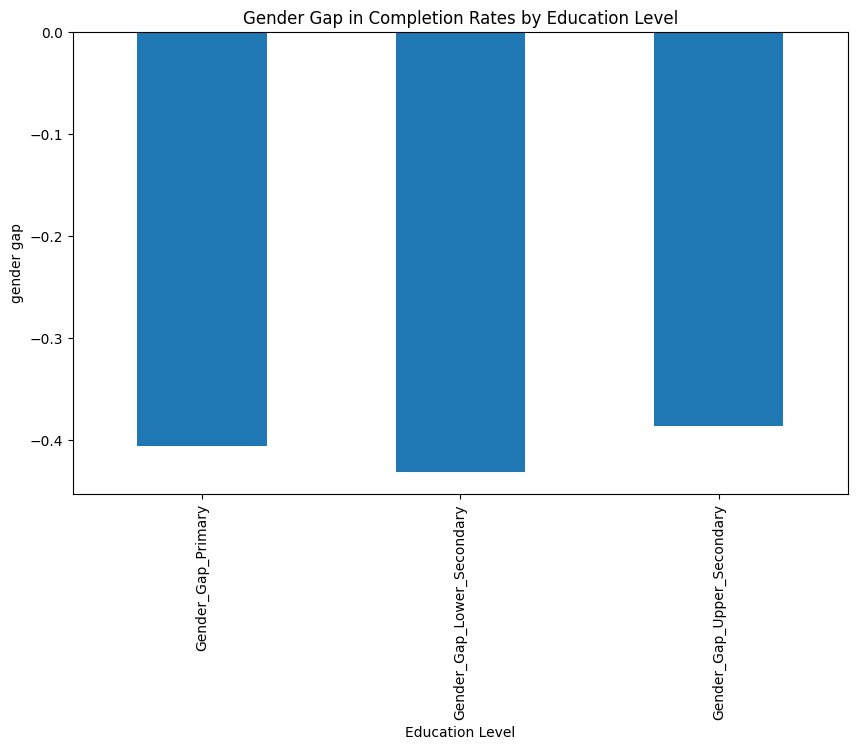

In [20]:
gender_gap_means = education[['Gender_Gap_Primary', 'Gender_Gap_Lower_Secondary', 'Gender_Gap_Upper_Secondary']].mean()
gender_gap_means.plot(kind='bar', figsize=(10, 6), title='Gender Gap in Completion Rates by Education Level')
plt.xlabel('Education Level')
plt.ylabel('gender gap')

In [27]:
education['Gender_Gap_Literacy'] = education['Youth_15_24_Literacy_Rate_Male'] - education['Youth_15_24_Literacy_Rate_Female']

high_gender_gap_countries = education.sort_values(by='Gender_Gap_Literacy', ascending=False).head(5)
low_gender_gap_countries = education.sort_values(by='Gender_Gap_Literacy').head(5)


print(f'Countries with High Gender Gap in Literacy Rates:\n{high_gender_gap_countries[["Countries and areas", "Gender_Gap_Literacy"]]}')
print(f'Countries with Low Gender Gap in Literacy Rates:\n{low_gender_gap_countries[["Countries and areas", "Gender_Gap_Literacy"]]}')

Countries with High Gender Gap in Literacy Rates:
          Countries and areas  Gender_Gap_Literacy
73                     Guinea                   27
34   Central African Republic                   19
0                 Afghanistan                   18
19                      Benin                   18
109                      Mali                   15
Countries with Low Gender Gap in Literacy Rates:
    Countries and areas  Gender_Gap_Literacy
149              Rwanda                   -5
60             Eswatini                   -3
78             Honduras                   -3
65                Gabon                   -3
178          East Timor                   -3


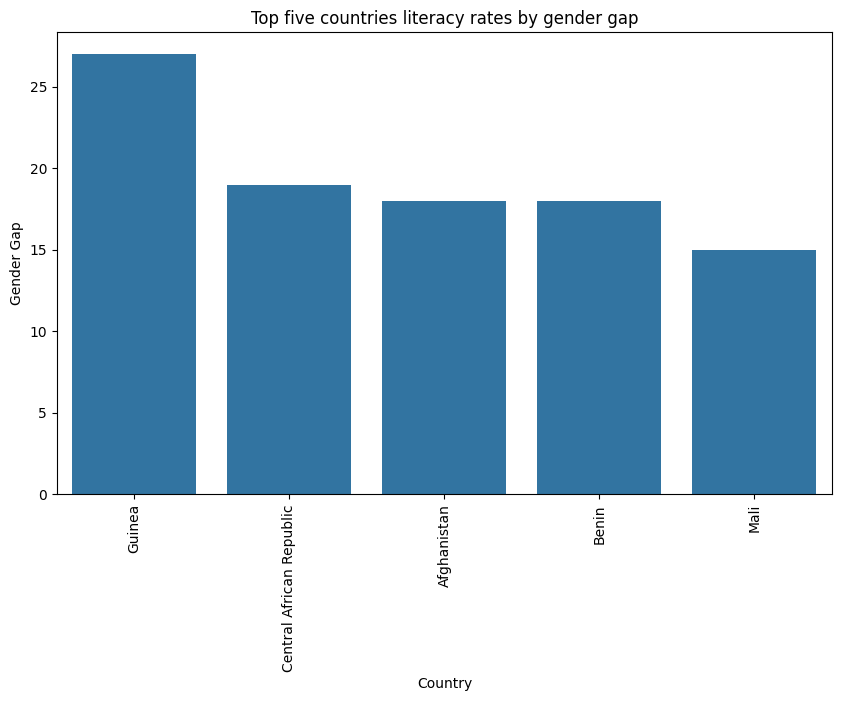

In [28]:

plt.figure(figsize=(10, 6))
sns.barplot(x="Countries and areas",y="Gender_Gap_Literacy",data=high_gender_gap_countries)
plt.xlabel('Country')
plt.ylabel('Gender Gap')
plt.title('Top five countries literacy rates by gender gap')
plt.xticks(rotation=90)
plt.show()